# AeroTwin — AI4I Fault Model Comparison
This notebook validates the tabular predictive-maintenance fault classification models (Logistic Regression, Random Forest, XGBoost).

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, average_precision_score, precision_recall_curve
from xgboost import XGBClassifier

# Configuration
SEED = 42
np.random.seed(SEED)

CACHE_DIR = "data/cache"
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook")

## 01. Load Processed Cache

In [2]:
cache_path = os.path.join(CACHE_DIR, "ai4i_processed.pkl")
with open(cache_path, "rb") as f:
    cache_data = pickle.load(f)

X_train = cache_data['X_train']
X_val = cache_data['X_val']
X_test = cache_data['X_test']

y_train = cache_data['y_train']
y_val = cache_data['y_val']
y_test = cache_data['y_test']

feature_names = cache_data['feature_names']

print(f"Loaded {X_train.shape[0]} train samples.")
print(f"Features: {feature_names}")

Loaded 7000 train samples.
Features: ['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Type_H', 'Type_L', 'Type_M']


## 02. Helper Evaluation Function
Given the high class imbalance, we prioritize Precision-Recall AUC (PR-AUC) and Recall over standard Accuracy.

In [3]:
def evaluate_model(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    pr_auc = average_precision_score(y_true, y_prob)
    return acc, prec, rec, f1, pr_auc

results = []

## 03. Train Logistic Regression
A simple linear baseline.

In [4]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(random_state=SEED, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)

lr_val_preds = lr_model.predict(X_val)
lr_val_probs = lr_model.predict_proba(X_val)[:, 1]

acc, prec, rec, f1, pr_auc = evaluate_model(y_val, lr_val_preds, lr_val_probs)
results.append({"Model": "Logistic Regression", "Val PR-AUC": pr_auc, "Val Recall": rec, "Val F1": f1})
print(f"LR PR-AUC: {pr_auc:.4f}, Recall: {rec:.4f}")

Training Logistic Regression...
LR PR-AUC: 0.3829, Recall: 0.7255


## 04. Train Random Forest
Robust non-linear tree baseline.

In [5]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=SEED, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_val_preds = rf_model.predict(X_val)
rf_val_probs = rf_model.predict_proba(X_val)[:, 1]

acc, prec, rec, f1, pr_auc = evaluate_model(y_val, rf_val_preds, rf_val_probs)
results.append({"Model": "Random Forest", "Val PR-AUC": pr_auc, "Val Recall": rec, "Val F1": f1})
print(f"RF PR-AUC: {pr_auc:.4f}, Recall: {rec:.4f}")

Training Random Forest...
RF PR-AUC: 0.6343, Recall: 0.5882


## 05. Train XGBoost
Strong gradient boosting framework.

In [6]:
print("Training XGBoost...")
# scale_pos_weight = sum(negative) / sum(positive)
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(
    n_estimators=200, 
    max_depth=6, 
    learning_rate=0.05, 
    random_state=SEED,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=10
)

# Fit using validation set for early stopping
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=0
)

xgb_val_preds = xgb_model.predict(X_val)
xgb_val_probs = xgb_model.predict_proba(X_val)[:, 1]

acc, prec, rec, f1, pr_auc = evaluate_model(y_val, xgb_val_preds, xgb_val_probs)
results.append({"Model": "XGBoost", "Val PR-AUC": pr_auc, "Val Recall": rec, "Val F1": f1})
print(f"XGB PR-AUC: {pr_auc:.4f}, Recall: {rec:.4f}")

Training XGBoost...
XGB PR-AUC: 0.5186, Recall: 0.7255


## 06. Model Comparison & Test Set Evaluation
We compare the validation performance and then evaluate the best model on the untouched test set.

In [7]:
comp_df = pd.DataFrame(results).sort_values("Val PR-AUC", ascending=False)
display(comp_df)

# Best Model Evaluation
best_model_name = comp_df.iloc[0]["Model"]
print(f"\\nSelected Best Model: {best_model_name}")

if best_model_name == "XGBoost":
    best_model = xgb_model
elif best_model_name == "Random Forest":
    best_model = rf_model
else:
    best_model = lr_model

test_preds = best_model.predict(X_test)
test_probs = best_model.predict_proba(X_test)[:, 1]

test_acc, test_prec, test_rec, test_f1, test_pr_auc = evaluate_model(y_test, test_preds, test_probs)

print(f"\\n--- Test Set Metrics ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall: {test_rec:.4f}")
print(f"F1-score: {test_f1:.4f}")
print(f"PR-AUC: {test_pr_auc:.4f}")

,Model,Val PR-AUC,Val Recall,Val F1
1,Random Forest,0.634280,0.588235,0.631579
2,XGBoost,0.518563,0.725490,0.451220
0,Logistic Regression,0.382902,0.725490,0.229814


\nSelected Best Model: Random Forest
\n--- Test Set Metrics ---
Accuracy: 0.9767
Precision: 0.6600
Recall: 0.6471
F1-score: 0.6535
PR-AUC: 0.7016


## 07. Precision-Recall Curve & Confusion Matrix

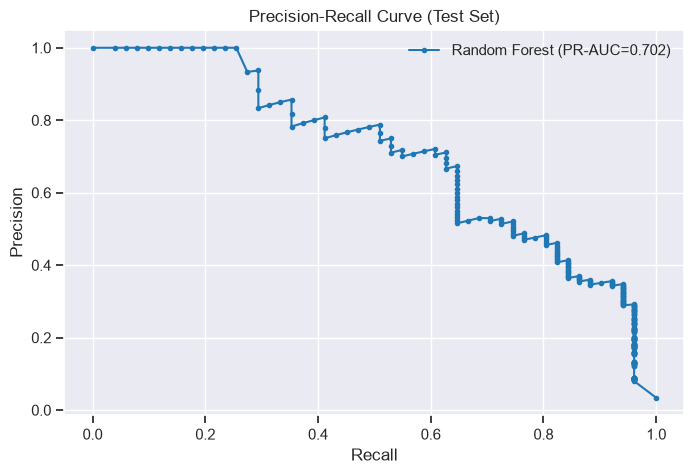

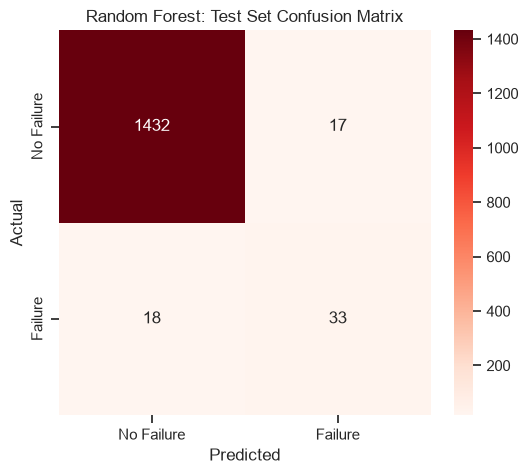

In [8]:
# PR Curve
precision, recall, _ = precision_recall_curve(y_test, test_probs)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, marker='.', label=f'{best_model_name} (PR-AUC={test_pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test Set)')
plt.legend()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.title(f"{best_model_name}: Test Set Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 08. Feature Importances

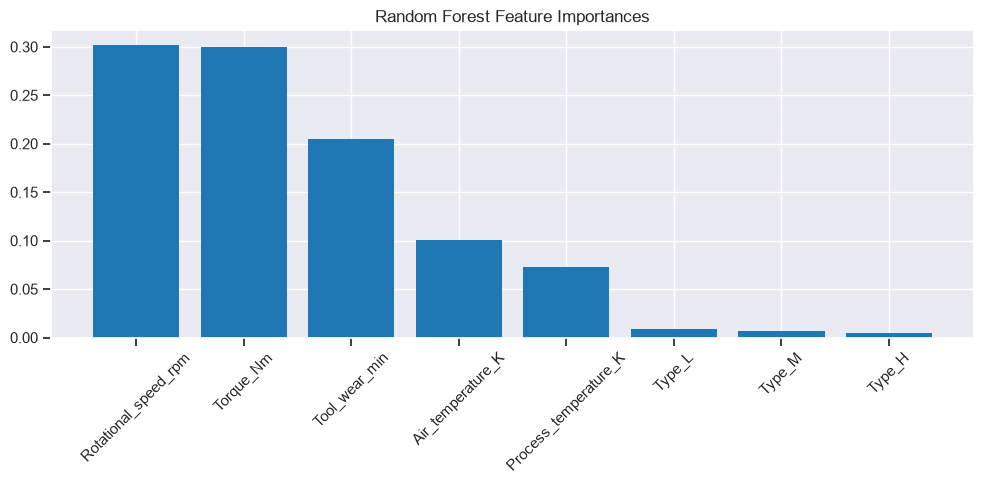

In [9]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(10, 5))
    plt.title(f"{best_model_name} Feature Importances")
    plt.bar(range(len(feature_names)), importances[indices], align="center")
    plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=45)
    plt.tight_layout()
    plt.show()

## 09. Save Final Artifacts

In [10]:
with open(os.path.join(MODELS_DIR, "best_ai4i_model.pkl"), "wb") as f:
    pickle.dump(best_model, f)
        
print("Pipeline complete!")

Pipeline complete!
